Solving truth QG on 128x256 grid...
Step 1000/150000 | CFL: 0.0462
Step 2000/150000 | CFL: 0.1090
Step 3000/150000 | CFL: 0.1486
Step 4000/150000 | CFL: 0.1513
Step 5000/150000 | CFL: 0.1546
Snapshot Stored: Step 5000/150000 | CFL: 0.1546
Step 6000/150000 | CFL: 0.1623
Step 7000/150000 | CFL: 0.1586
Step 8000/150000 | CFL: 0.1984
Step 9000/150000 | CFL: 0.2113
Step 10000/150000 | CFL: 0.2524
Step 11000/150000 | CFL: 0.2617
Step 12000/150000 | CFL: 0.2777
Step 13000/150000 | CFL: 0.2887
Step 14000/150000 | CFL: 0.3442
Step 15000/150000 | CFL: 0.3160
Step 16000/150000 | CFL: 0.3797
Step 17000/150000 | CFL: 0.3682
Step 18000/150000 | CFL: 0.4010
Step 19000/150000 | CFL: 0.4200
Step 20000/150000 | CFL: 0.4248
Step 21000/150000 | CFL: 0.4522
Step 22000/150000 | CFL: 0.4795
Step 23000/150000 | CFL: 0.4946
Step 24000/150000 | CFL: 0.5057
Step 25000/150000 | CFL: 0.5151
Step 26000/150000 | CFL: 0.5306
Step 27000/150000 | CFL: 0.5567
Step 28000/150000 | CFL: 0.5770
Step 29000/150000 | CFL: 0.59

C:\Users\asojitra\AppData\Local\Temp\ipykernel_5368\4220440824.py:247: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


GIF saved successfully -> vorticity_evolution.gif


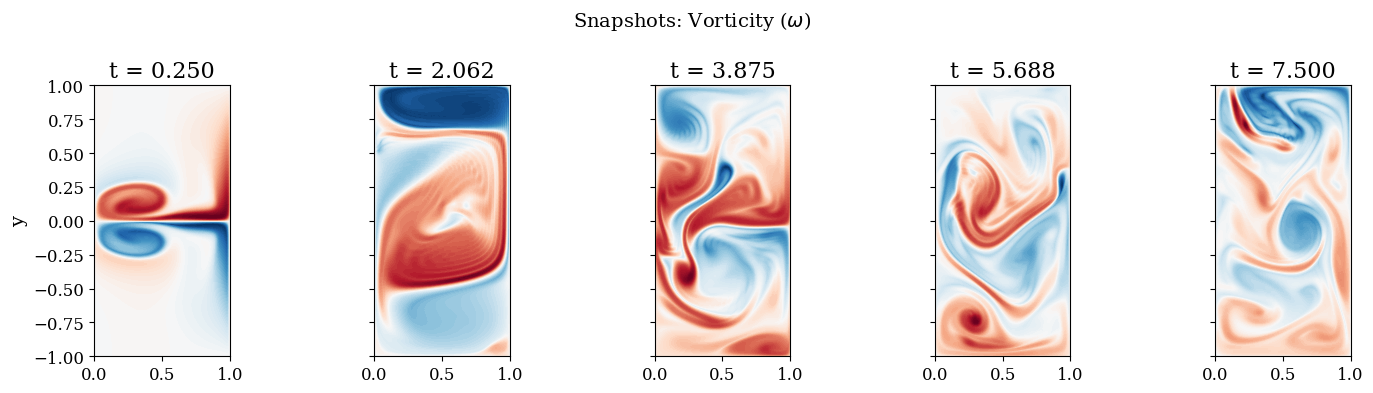

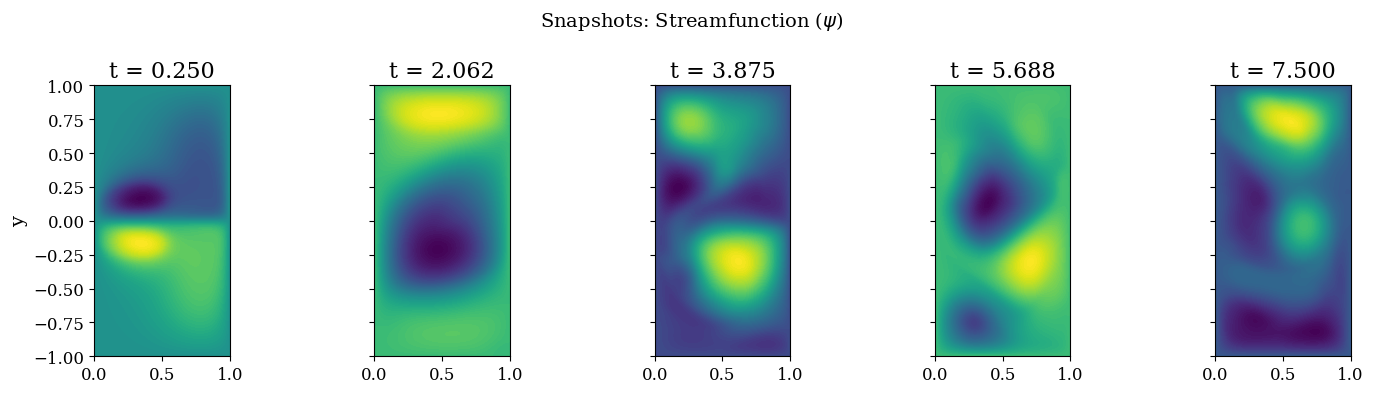

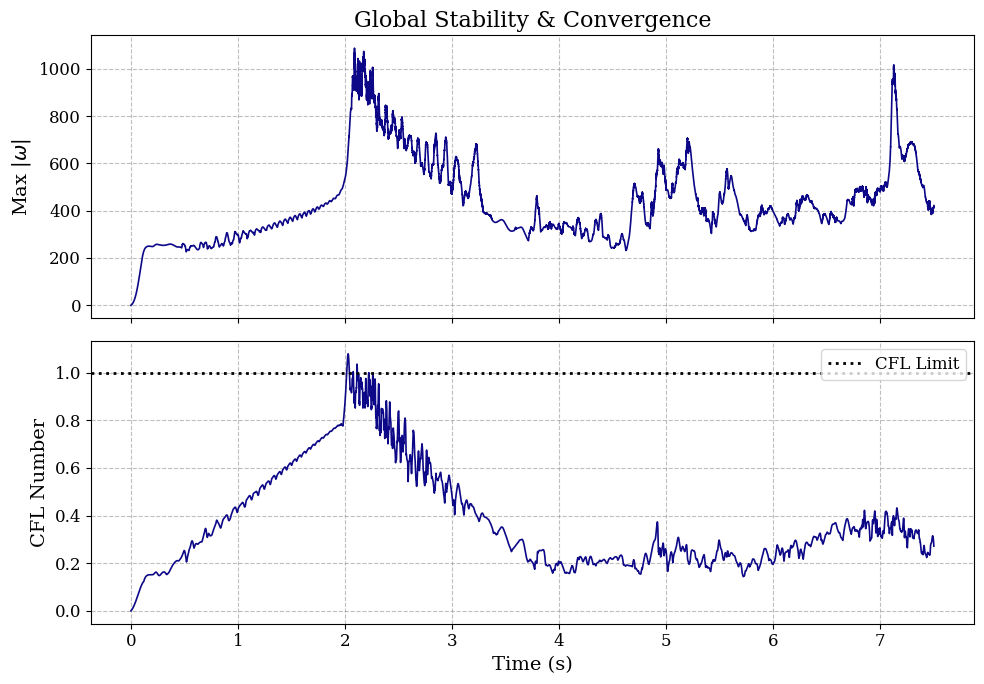

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import matplotlib.pyplot as plt
import time as tm
from numba import njit
from scipy.fft import dst, idst
import imageio.v2 as imageio

# ============================================================
# CONFIGURATION
# ============================================================
config = {
    "NX": 128,
    "NY": 256,
    "Re": 4.5e2,
    "Ro": 0.0036,
    "NT": 150000,
    "NS": 5000,
    "NF": 5,
    "dt": 5.0e-5,
    "LX": 1.0,
    "LY": 2.0,
}

checkpoint_step = 90000
checkpoint_file = f"qg_truth_checkpoint_step_{checkpoint_step}.npz"

# ---- GIF settings ----
make_gif = True
gif_stride = 200         # save one frame every 200 time steps
gif_filename = "vorticity_evolution.gif"
gif_fps = 15

# ============================================================
# DERIVED PARAMETERS
# ============================================================
dx = config["LX"] / config["NX"]
dy = config["LY"] / config["NY"]
nt, ns, nf, dt = config["NT"], config["NS"], config["NF"], config["dt"]
snap_steps = np.linspace(ns, nt, nf, dtype=np.int64)

# ============================================================
# NUMERICAL ROUTINES
# ============================================================
@njit
def compute_physics_cfl(nx, ny, dx, dy, dt, s):
    u_vel = (s[1:nx, 2:ny+1] - s[1:nx, 0:ny-1]) / (2.0 * dy)
    v_vel = -(s[2:nx+1, 1:ny] - s[0:nx-1, 1:ny]) / (2.0 * dx)

    max_u = np.max(np.abs(u_vel))
    max_v = np.max(np.abs(v_vel))
    return dt * max(max_u/dx, max_v/dy)


def fst_poisson_2d(nx, ny, dx, dy, f):
    f_interior = f[1:nx, 1:ny]
    ft = idst(idst(f_interior, axis=0, type=1), axis=1, type=1)

    i = np.arange(1, nx).reshape(-1, 1)
    j = np.arange(1, ny)

    eigen_x = 2.0 / (dx**2) * (np.cos(np.pi * i / nx) - 1.0)
    eigen_y = 2.0 / (dy**2) * (np.cos(np.pi * j / ny) - 1.0)

    u_coeff = ft / (eigen_x + eigen_y)

    u_interior = dst(dst(u_coeff, axis=0, type=1), axis=1, type=1)
    u = np.zeros((nx + 1, ny + 1))
    u[1:nx, 1:ny] = u_interior
    return u


@njit
def rhs_arakawa(nx, ny, dx, dy, re, ro, w, s, fs):
    gg = 1.0 / (4.0 * dx * dy)
    hh = 1.0 / 3.0

    j1 = gg * ((w[2:nx+1, 1:ny] - w[0:nx-1, 1:ny]) * (s[1:nx, 2:ny+1] - s[1:nx, 0:ny-1]) -
               (w[1:nx, 2:ny+1] - w[1:nx, 0:ny-1]) * (s[2:nx+1, 1:ny] - s[0:nx-1, 1:ny]))

    j2 = gg * (w[2:nx+1, 1:ny] * (s[2:nx+1, 2:ny+1] - s[2:nx+1, 0:ny-1]) -
               w[0:nx-1, 1:ny] * (s[0:nx-1, 2:ny+1] - s[0:nx-1, 0:ny-1]) -
               w[1:nx, 2:ny+1] * (s[2:nx+1, 2:ny+1] - s[0:nx-1, 2:ny+1]) +
               w[1:nx, 0:ny-1] * (s[2:nx+1, 0:ny-1] - s[0:nx-1, 0:ny-1]))

    j3 = gg * (w[2:nx+1, 2:ny+1] * (s[1:nx, 2:ny+1] - s[2:nx+1, 1:ny]) -
               w[0:nx-1, 0:ny-1] * (s[0:nx-1, 1:ny] - s[1:nx, 0:ny-1]) -
               w[0:nx-1, 2:ny+1] * (s[1:nx, 2:ny+1] - s[0:nx-1, 1:ny]) +
               w[2:nx+1, 0:ny-1] * (s[2:nx+1, 1:ny] - s[1:nx, 0:ny-1]))

    jac = (j1 + j2 + j3) * hh

    lap = (1.0/dx**2) * (w[2:nx+1, 1:ny] - 2*w[1:nx, 1:ny] + w[0:nx-1, 1:ny]) + \
          (1.0/dy**2) * (w[1:nx, 2:ny+1] - 2*w[1:nx, 1:ny] + w[1:nx, 0:ny-1])

    cor = (1.0/(2.0*dx)) * (s[2:nx+1, 1:ny] - s[0:nx-1, 1:ny])

    rhs = np.zeros((nx + 1, ny + 1))
    rhs[1:nx, 1:ny] = -jac + lap/re + fs[1:nx, 1:ny] + cor/ro
    return rhs


def rk3_step(wen, sen, fs, config, dx, dy, dt):
    nx = config["NX"]
    ny = config["NY"]
    re = config["Re"]
    ro = config["Ro"]

    r1 = rhs_arakawa(nx, ny, dx, dy, re, ro, wen, sen, fs)
    t1 = wen + dt * r1
    s1 = fst_poisson_2d(nx, ny, dx, dy, t1)

    r2 = rhs_arakawa(nx, ny, dx, dy, re, ro, t1, s1, fs)
    t2 = 0.75 * wen + 0.25 * t1 + 0.25 * dt * r2
    s2 = fst_poisson_2d(nx, ny, dx, dy, t2)

    r3 = rhs_arakawa(nx, ny, dx, dy, re, ro, t2, s2, fs)
    wen_new = (1.0 / 3.0) * wen + (2.0 / 3.0) * t2 + (2.0 / 3.0) * dt * r3
    sen_new = fst_poisson_2d(nx, ny, dx, dy, wen_new)

    return wen_new, sen_new

# ============================================================
# GRID / FORCING
# ============================================================
x_grid = np.linspace(0.0, config["LX"], config["NX"] + 1)
y_grid = np.linspace(-0.5 * config["LY"], 0.5 * config["LY"], config["NY"] + 1)
X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')

fs = np.zeros((config["NX"] + 1, config["NY"] + 1))
fs[1:-1, 1:-1] = (1.0 / config["Ro"]) * np.sin(np.pi * Y[1:-1, 1:-1])

# ============================================================
# INITIALIZATION
# ============================================================
wen = np.zeros((config["NX"] + 1, config["NY"] + 1))
sen = np.zeros((config["NX"] + 1, config["NY"] + 1))

max_w_hist = np.zeros(nt)
cfl_hist = np.zeros(nt)
snap_w, snap_s, snap_times = [], [], []

# ---- GIF storage ----
gif_frames = []
gif_times = []

snap_steps_set = set(snap_steps.tolist())

# ============================================================
# TIME INTEGRATION
# ============================================================
clock_start = tm.time()
print(f"Solving truth QG on {config['NX']}x{config['NY']} grid...")

saved_checkpoint = False

for k in range(nt):
    step = k + 1

    wen, sen = rk3_step(wen, sen, fs, config, dx, dy, dt)

    cfl = compute_physics_cfl(config["NX"], config["NY"], dx, dy, dt, sen)
    max_w_hist[k] = np.max(np.abs(wen))
    cfl_hist[k] = cfl

    if step % 1000 == 0:
        print(f"Step {step}/{nt} | CFL: {cfl:.4f}")

    if step == checkpoint_step:
        np.savez_compressed(
            checkpoint_file,
            wen=wen,
            sen=sen,
            step=step,
            dx=dx,
            dy=dy,
            dt=dt,
            NX=config["NX"],
            NY=config["NY"],
            Re=config["Re"],
            Ro=config["Ro"],
            LX=config["LX"],
            LY=config["LY"],
        )
        saved_checkpoint = True
        print(f"Checkpoint saved at step {step} -> {checkpoint_file}")

    if step in snap_steps_set:
        print(f"Snapshot Stored: Step {step}/{nt} | CFL: {cfl:.4f}")
        snap_w.append(np.copy(wen))
        snap_s.append(np.copy(sen))
        snap_times.append(step * dt)

    # Save sparse frames for GIF
    if make_gif and (step % gif_stride == 0 or step == 1 or step == nt):
        gif_frames.append(np.copy(wen))
        gif_times.append(step * dt)

print(f"Total Computation Time: {tm.time() - clock_start:.2f} s")

if not saved_checkpoint:
    print("Warning: checkpoint step was not reached, so no checkpoint was saved.")

# ============================================================
# BUILD GIF
# ============================================================

import matplotlib as mpl

def set_plot_params():
    """
    Matplotlib's rcParams for consistent, publication-quality plots.
    """
    ## Figure settings
    mpl.rcParams['figure.figsize'] = (8, 6)       # Figure size in inches
    mpl.rcParams['figure.dpi'] = 100              # (Display) Figure resolution
    mpl.rcParams['savefig.dpi'] = 300             # Resolution when saving figures

    ## Font settings (Standard 16-14-12 config.)
    mpl.rcParams['font.family'] = 'serif'         # Serif fonts
    mpl.rcParams['font.size'] = 12                # Base font size
    mpl.rcParams['axes.titlesize'] = 16           # Title font size for axes
    mpl.rcParams['axes.labelsize'] = 14           # Font size for x and y labels
    mpl.rcParams['xtick.labelsize'] = 12          # Font size for x-tick labels
    mpl.rcParams['ytick.labelsize'] = 12          # Font size for y-tick labels
    mpl.rcParams['legend.fontsize'] = 12          # Legend font size

    ## Line settings
    mpl.rcParams['lines.linewidth'] = 2           # Default line width
    mpl.rcParams['lines.markersize'] = 6          # Marker size for plots

    ## Contour plot settings
    mpl.rcParams['contour.negative_linestyle'] = 'solid'

    ## Grid settings
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    ## Color presets (Plasma-ish color scheme)
    mpl.rcParams['image.cmap'] = 'plasma' # Can be changed to "jet", "viridis", etc.

    ## Default color cycle for line plots using the plasma colormap.
    plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.
    num_colors = 10
    colors = [plasma_cmap(i) for i in np.linspace(0, 1, num_colors)]
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)
    
set_plot_params()

if make_gif and len(gif_frames) > 0:
    print(f"Building GIF with {len(gif_frames)} frames...")

    # Use a fixed color scale across all frames
    w_abs_max = max(np.max(np.abs(wf)) for wf in gif_frames)
    levels = np.linspace(-w_abs_max, w_abs_max, 100)

    temp_png_files = []

    for i, (wframe, tframe) in enumerate(zip(gif_frames, gif_times)):
        fig, ax = plt.subplots(figsize=(7, 5))
        contour = ax.contourf(X, Y, wframe,100, cmap='RdBu_r', extend='both')
        cbar = plt.colorbar(contour, ax=ax)
        cbar.set_label(r'Vorticity , $\omega$')
        # ax.set_title(rf"Vorticity Evolution at $t = {tframe:.4f}$")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect('equal')
        plt.tight_layout()

        temp_png = f"_tmp_vorticity_frame_{i:05d}.png"
        fig.savefig(temp_png, dpi=300, bbox_inches='tight')
        plt.close(fig)
        temp_png_files.append(temp_png)

    with imageio.get_writer(gif_filename, mode='I', fps=gif_fps) as writer:
        for fname in temp_png_files:
            image = imageio.imread(fname)
            writer.append_data(image)

    for fname in temp_png_files:
        if os.path.exists(fname):
            os.remove(fname)

    print(f"GIF saved successfully -> {gif_filename}")

# ============================================================
# PLOTTING
# ============================================================
fig1, axs1 = plt.subplots(1, nf, figsize=(nf * 3, 4), sharey=True)
if nf == 1:
    axs1 = [axs1]
for i in range(nf):
    cf1 = axs1[i].contourf(X, Y, snap_w[i], 100, cmap='RdBu_r')
    axs1[i].set_title(f"t = {snap_times[i]:.3f}")
    axs1[i].set_aspect('equal')
axs1[0].set_ylabel("y")
fig1.suptitle(r"Snapshots: Vorticity ($\omega$)", fontsize=14)
plt.tight_layout()

fig2, axs2 = plt.subplots(1, nf, figsize=(nf * 3, 4), sharey=True)
if nf == 1:
    axs2 = [axs2]
for i in range(nf):
    cf2 = axs2[i].contourf(X, Y, snap_s[i], 100, cmap='viridis')
    axs2[i].set_title(f"t = {snap_times[i]:.3f}")
    axs2[i].set_aspect('equal')
axs2[0].set_ylabel("y")
fig2.suptitle(r"Snapshots: Streamfunction ($\psi$)", fontsize=14)
plt.tight_layout()

fig3, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
t_axis = np.linspace(0, nt * dt, nt)

ax1.plot(t_axis, max_w_hist, linewidth=1.2)
ax1.set_title("Global Stability & Convergence")
ax1.set_ylabel(r"Max $|\omega|$")
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(t_axis, cfl_hist, linewidth=1.2)
ax2.axhline(y=1.0, color='black', linestyle=':', label='CFL Limit')
ax2.set_ylabel("CFL Number")
ax2.set_xlabel("Time (s)")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

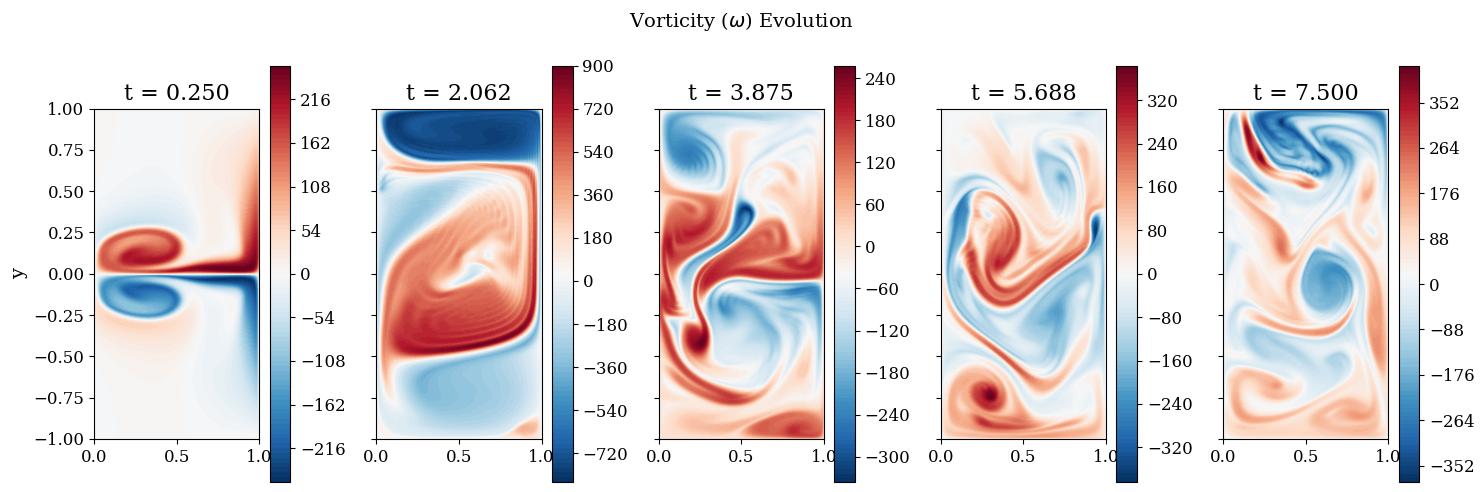

In [16]:
fig1, axs1 = plt.subplots(1, nf, figsize=(nf * 3, 5), sharey=True)

if nf == 1:
    axs1 = [axs1]

for i in range(nf):
    cf1 = axs1[i].contourf(X, Y, snap_w[i], 100, cmap='RdBu_r')
    axs1[i].set_title(f"t = {snap_times[i]:.3f}")
    axs1[i].set_aspect('equal')

    # Colorbar for this subplot
    cbar = fig1.colorbar(cf1, ax=axs1[i])
    # cbar.set_label(r'$\omega$')

axs1[0].set_ylabel("y")

fig1.suptitle(r"Vorticity ($\omega$) Evolution", fontsize=14)

plt.tight_layout()
plt.show()